# Crop Yield Prediction using  Machine Learning 

### PROBLEM STATEMENT 

* Crop yield prediction is a challenging task due to the influence of multiple factors such as area, crop type, and environmental conditions.
* Existing methods often lack accuracy and fail to consider important variables.
* Therefore, there is a need to develop a machine learning model to predict crop yield more effectively.

![Crop yield](sddefault.jpg)

#### LIBRARIES ####

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### DATASET ####

In [3]:
df = pd.read_csv("crop_production.csv")
df

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
...,...,...,...,...,...,...,...
246086,West Bengal,PURULIA,2014,Summer,Rice,306.0,801.0
246087,West Bengal,PURULIA,2014,Summer,Sesamum,627.0,463.0
246088,West Bengal,PURULIA,2014,Whole Year,Sugarcane,324.0,16250.0
246089,West Bengal,PURULIA,2014,Winter,Rice,279151.0,597899.0


In [9]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [13]:
df.shape

(246091, 7)

In [14]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [16]:
df.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [17]:
df.isnull()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
246086,False,False,False,False,False,False,False
246087,False,False,False,False,False,False,False
246088,False,False,False,False,False,False,False
246089,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

In [7]:
df = df[df['Area'] != 0]
df['Yield'] = df['Production'] / df['Area']

In [30]:
y = df['Yield']

## DISTRIBUTION OF YIELD 

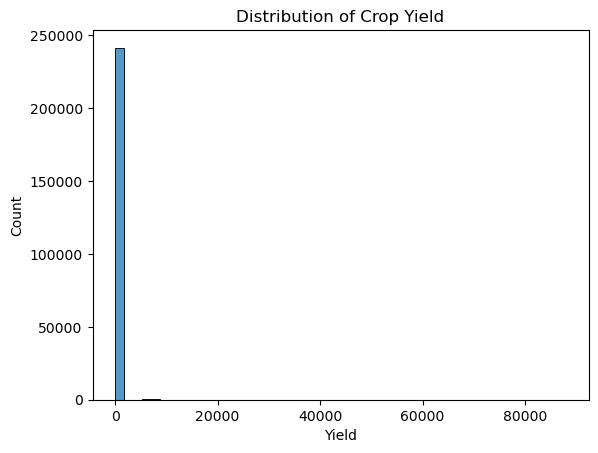

In [16]:
plt.figure()
sns.histplot(df['Yield'], bins=50)
plt.title("Distribution of Crop Yield")
plt.show()

## TOP CROPS BY PRODUCTION 

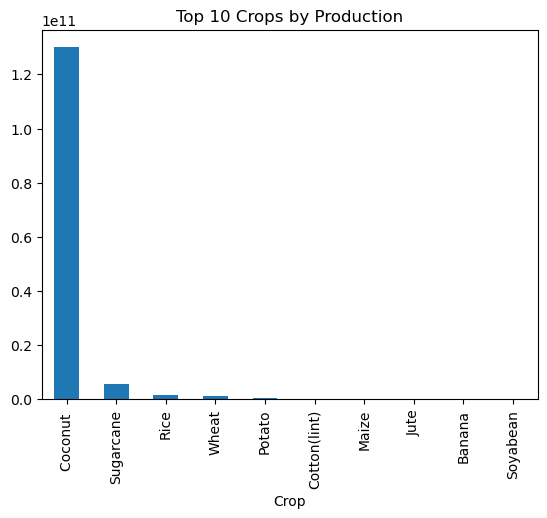

In [19]:
top_crops = df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_crops.plot(kind='bar')
plt.title("Top 10 Crops by Production")
plt.show()

## STATE-WISE PRODUCTION 

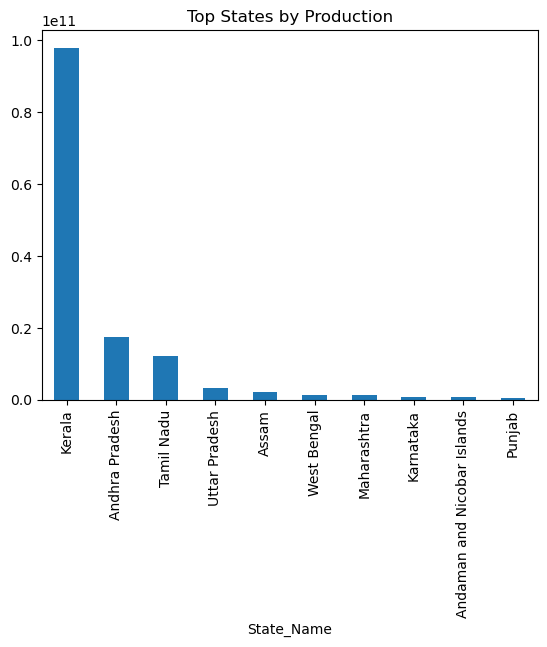

In [18]:
state_prod = df.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head(10)

plt.figure()
state_prod.plot(kind='bar')
plt.title("Top States by Production")
plt.show()

## SEASON-WISE ANALYSIS 

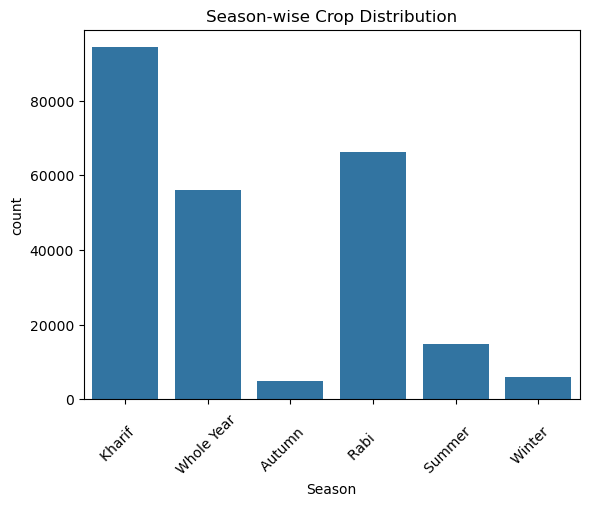

In [20]:
plt.figure()
sns.countplot(x='Season', data=df)
plt.xticks(rotation=45)
plt.title("Season-wise Crop Distribution")
plt.show()

## AREA vs PRODUCTION 

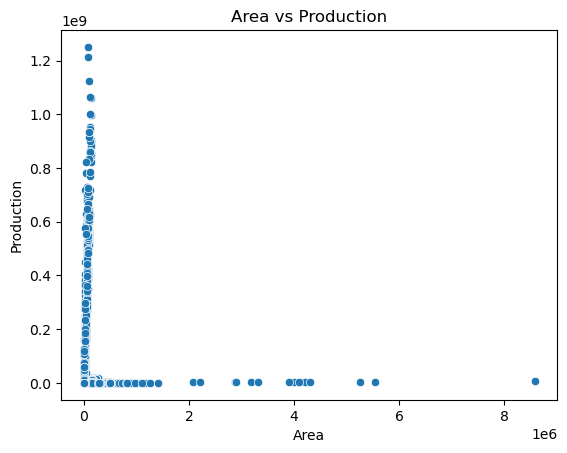

In [21]:
plt.figure()
sns.scatterplot(x='Area', y='Production', data=df)
plt.title("Area vs Production")
plt.show()

## CORRELATION HEATMAP 

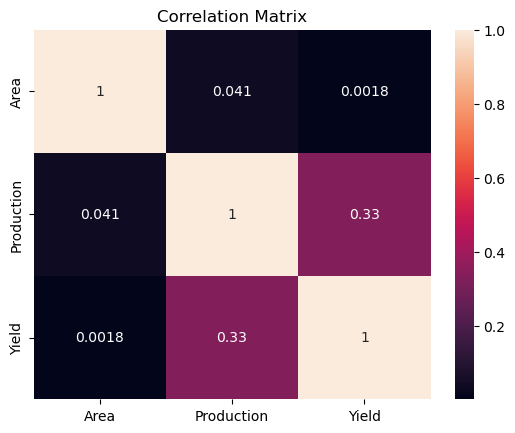

In [22]:
plt.figure()
sns.heatmap(df[['Area', 'Production', 'Yield']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## CONVERT CATEGORICAL DATA 

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['State_Name'] = le.fit_transform(df['State_Name'])
df['District_Name'] = le.fit_transform(df['District_Name'])
df['Season'] = le.fit_transform(df['Season'])
df['Crop'] = le.fit_transform(df['Crop'])

## DEFINE FEATURES (X) AND TARGET (y)

In [10]:
X = df[['State_Name', 'District_Name', 'Season', 'Crop', 'Area']]
y = df['Yield']

## SPLIT DATA  

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## TRAIN MODEL 

In [35]:
model = RandomForestRegressor(n_estimators=20)
model.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.5736880595904541


## IMPROVE RANDOM FOREST

In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
print("Improved R2 Score:", r2_score(y_test, y_pred))

Improved R2 Score: 0.5913607755109054


## Linear Regression

In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.006105872647599764


## DECISION TREE

In [44]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.5205410740571388


## CONCLUSION ##

#### In this project, machine learning models were used to predict crop yield. Different models such as Random Forest, Decision Tree, and Linear Regression were implemented and compared. Among them, Random Forest achieved the best performance with an R² score of approximately 0.59. The results show that machine learning can be effectively used for agricultural prediction. However, including more features like rainfall and temperature could further improve the model.